In [1]:
import pandas as pd
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns

def parse_yaml_file(filepath):
    """
    Parses a single YAML file and extracts relevant data.

    Args:
        filepath (str): The full path to the YAML file.

    Returns:
        dict: A dictionary containing the parsed data with the filename as a key.
    """
    with open(filepath, 'r') as file:
        data = yaml.safe_load(file)
    return data

def process_data_for_dataframe(data, source_name):
    """
    Processes the parsed YAML data into a flat format suitable for a Pandas DataFrame.

    Args:
        data (dict): The dictionary parsed from a YAML file.
        source_name (str): The name of the source (e.g., directory name or filename prefix).

    Returns:
        list: A list of dictionaries, each representing a row in the DataFrame.
    """
    rows = []
    on_target= {}
    off_target = {}
    for model_name, model_data in data.items():

        row_base = {
            'source': source_name,
            'model': model_name,
            'clustering_score': model_data.get('clustering_score'),
            'total_number_edges': model_data.get('total_number_edges')
        }
        
        for key, value in model_data.items():
            print(key)
            if isinstance(value, dict) and key.startswith('net_'):
                # Extract net-specific details
                row = row_base.copy()
                row['net_id'] = key
                row['net_size'] = value.get('net_size')
                row['edge_overlap'] = value.get('edge_overlap')
                row['overlap_percent'] = value.get('overlap_percent')
                row['reverse_overlap_percent'] = value.get('reverse_overlap_percent')
                rows.append(row)
            
            
            elif  key  == 'on_grn_overlap':
                on_target = insert_overlap(on_target, model_name, value)
             
            elif  key  == 'off_grn_overlap':
                off_target = insert_overlap(off_target, model_name, value)
            elif not isinstance(value, dict) and key not in ['clustering_score', 'total_number_edges']:
                # Handle other top-level keys if they exist and are not dictionaries
                # This part might need adjustment based on expected YAML structure variations
                row = row_base.copy()
                row[key] = value
                rows.append(row)

                
        # If there are no 'net_' entries, still add a row for the main model data
        if not any(k.startswith('net_') for k in model_data.keys()):
            rows.append(row_base)
    return rows, on_target, off_target


def insert_overlap(dicti, model, values):
    if model in dicti.keys():
        dicti[model]  = dicti[model]+values
    else:
        dicti[model] = values
    return dicti


def create_dataframe_from_yaml_data(yaml_data_collection):
    """
    Creates a pandas DataFrame from a collection of processed YAML data.

    Args:
        yaml_data_collection (list): A list of processed data rows.

    Returns:
        pandas.DataFrame: The resulting DataFrame.
    """
    return pd.DataFrame(yaml_data_collection)

def parse_yaml_files_in_directory(directory_path):
    """
    Parses all YAML files in a given directory and consolidates their data into a DataFrame.

    Args:
        directory_path (str): The path to the directory containing the YAML files.

    Returns:
        pandas.DataFrame: A DataFrame containing data from all parsed YAML files.
    """
    all_processed_rows = []
    all_on_target = []
    all_off_target = []
    # Assuming the directory name itself is the 'source' or if you have a specific file naming convention.
    # For this example, I'll use the directory name as the source.
    source_name = os.path.basename(directory_path.rstrip(os.sep))

    for dirname in os.listdir(directory_path):
        filepath = os.path.join(directory_path, dirname, 'results.yaml')
        print(f"Parsing {filepath}...")
        raw_data = parse_yaml_file(filepath)
        processed_rows, ont, oft = process_data_for_dataframe(raw_data, source_name)
        all_processed_rows.extend(processed_rows)
        all_on_target.append(ont)
        all_off_target.append(oft)
    
    oft = merge_dictionaries(all_off_target)
    ont = merge_dictionaries(all_on_target)


    return create_dataframe_from_yaml_data(all_processed_rows), ont, oft

def merge_dictionaries(oft):
    a_ot = {}    
    for o in oft:
        for k in o:
            if k in a_ot:
                a_ot[k] = a_ot[k]+o[k]
            else:
                a_ot[k] = o[k]
    return a_ot

In [2]:

# Create dummy files for demonstration purposes
# In a real scenario, these files would already exist in your directory.
results_directory = "/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries"


# Now, call the function with the path to your directory
# Replace 'my_yaml_results' with the actual path to your directory containing the YAML files.
df, ont, oft = parse_yaml_files_in_directory(results_directory)



Parsing /data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_105_14145_net_76_12762_net_51_13833/results.yaml...
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_number_edges
clustering_score
net_105_14145
net_76_12762
total_numbe

In [ ]:
df[df.overlap_percent>0]

,source,model,clustering_score,total_number_edges,net_id,net_size,edge_overlap,overlap_percent,reverse_overlap_percent
1,summaries,netmap_config_10,1.000,12021,net_76_12762,163,18,0.110429,0.110429
2,summaries,netmap_config_11,1.000,23620,net_105_14145,110,35,0.318182,0.318182
3,summaries,netmap_config_11,1.000,23620,net_76_12762,163,72,0.441718,0.441718
4,summaries,netmap_config_12,1.000,53763,net_105_14145,110,110,1.000000,1.000000
5,summaries,netmap_config_12,1.000,53763,net_76_12762,163,163,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...
373,summaries,netmap_config_8,1.000,18621,net_51_13496,111,46,0.414414,0.414414
374,summaries,netmap_config_9,1.000,18667,net_149_13167,182,10,0.054945,0.054945
375,summaries,netmap_config_9,1.000,18667,net_51_13496,111,41,0.369369,0.369369
376,summaries,scgenerai_config,0.501,33411,net_149_13167,182,60,0.329670,0.329670


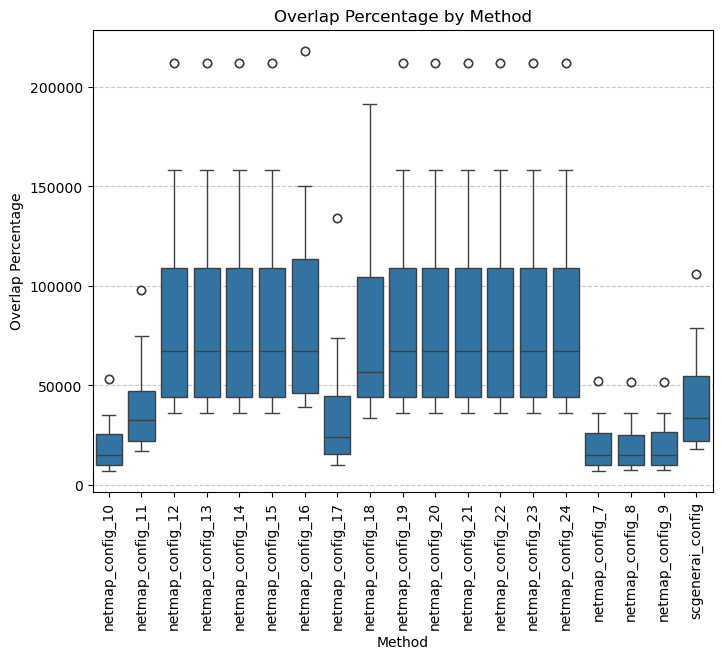

In [3]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='model', y='total_number_edges', data=df)



plt.title('Overlap Percentage by Method')
plt.xlabel('Method')
plt.ylabel('Overlap Percentage')
plt.xticks(rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

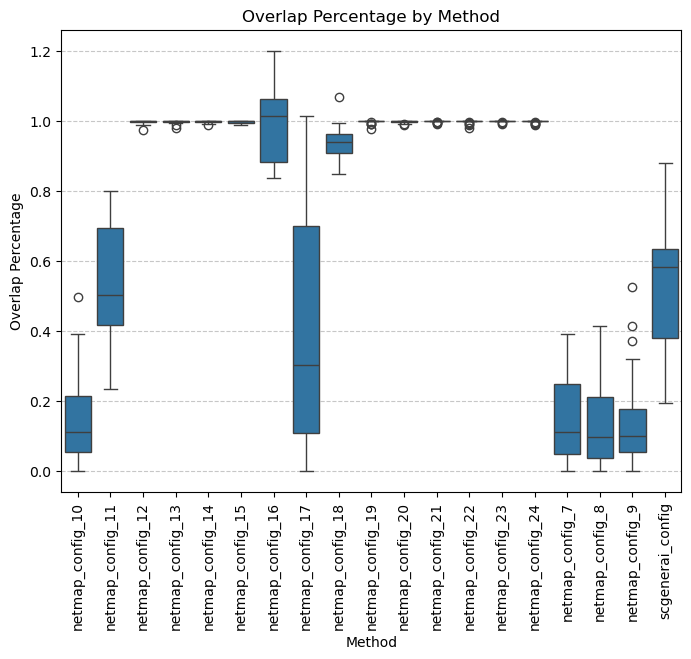

In [4]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='model', y='overlap_percent', data=df)



plt.title('Overlap Percentage by Method')
plt.xlabel('Method')
plt.ylabel('Overlap Percentage')
plt.xticks(rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

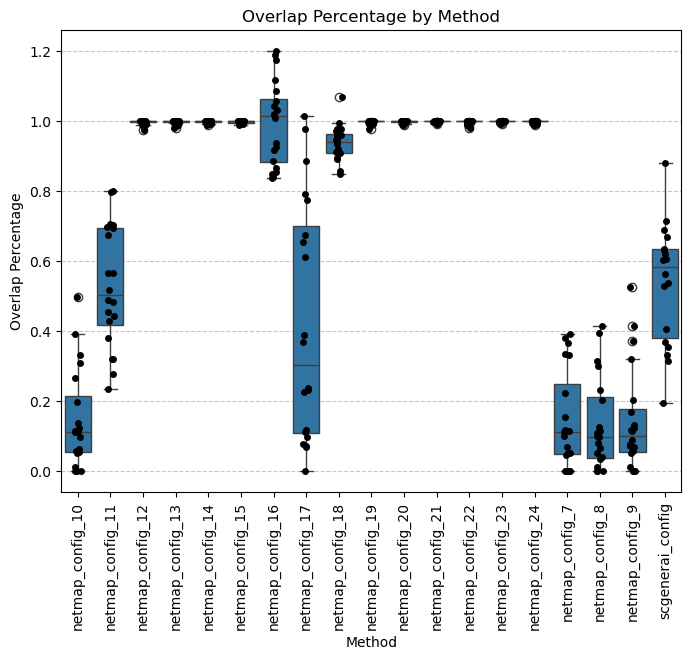

In [5]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='model', y='reverse_overlap_percent', data=df)
sns.stripplot(x='model', y='reverse_overlap_percent', data=df, color='black', size=5, jitter=True) # Adds individual points
plt.title('Overlap Percentage by Method')
plt.xlabel('Method')
plt.ylabel('Overlap Percentage')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

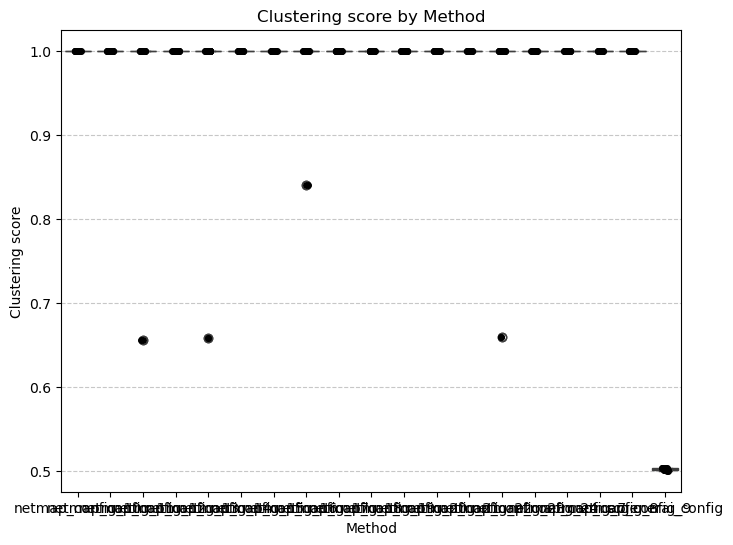

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='model', y='clustering_score', data=df)
sns.stripplot(x='model', y='clustering_score', data=df, color='black', size=5, jitter=True) # Adds individual points
plt.title('Clustering score by Method')
plt.xlabel('Method')
plt.ylabel('Clustering score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
import pandas as pd
import yaml
import os

def parse_network_paths_data(data):
    """
    Parses the provided dictionary data into a list of dictionaries,
    suitable for creating a Pandas DataFrame.

    Args:
        data (dict): The dictionary parsed from the YAML-like structure.

    Returns:
        list: A list of dictionaries, each representing a row in the DataFrame.
    """
    rows = []
    for net_id, net_data in data.items():
        # Iterate through each method (csnet, netmap, scgenerai, data_simulation)
        for method_name, method_details in net_data.items():
            if method_name == 'data_simulation':
                # Data simulation has 'configs' and 'data_path' keys
                continue                
            else:
                # Other methods have 'config_easy' which contains 'config' and 'result'
                result_path = method_details.get('config_easy', {}).get('result')

            rows.append({
                'network_id': net_id,
                'method': method_name,
                'result_path': result_path
            })
    return rows

import os.path as op
import numpy as np
def create_dataframe_from_paths(data_to_parse):
    """
    Creates a Pandas DataFrame from the parsed network path data.

    Args:
        data_to_parse (dict): The raw dictionary content from the YAML-like structure.

    Returns:
        pandas.DataFrame: A DataFrame containing the network IDs, methods,
                          and their corresponding config and result paths.
    """
    processed_rows = parse_network_paths_data(data_to_parse)
    df = pd.DataFrame(processed_rows)
    return df


def read_all_timings(data):
    times = []
    for row, content in data.iterrows():
        try:
            mylist = content['result_path'].split('/')[-4:]
            time = parse_yaml_file(op.join(content['result_path'], 'results.yaml'))
            mylist.append(time['time_elapsed_total'])
            mylist.append(time[f'time_elapsed_{mylist[0]}'])
            times.append(mylist)
        except:
            continue
        
    times = pd.DataFrame(np.stack(times))
    times.columns = ['method', 'method_config', 'data_config', 'net', 'time_total', 'time_method']
    times['time_method'] = times['time_method'].astype( float)
    times['time_total'] = times['time_total'].astype( float)
    
    return times

In [8]:
yaml_content = parse_yaml_file('/data_nfs/og86asub/netmap/netmap-evaluation/all_tests.yaml')

In [9]:

df = create_dataframe_from_paths(yaml_content)



In [12]:
import os
import yaml

def read_all_results(root_dir):
    """
    Reads all YAML files in a tree of directories starting from root_dir.

    Args:
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(('overlaps.tsv', 'overlaps.tsv')):
                filepath = os.path.join(dirpath, filename)
                print(filepath)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t')
                    overlaps['net'] = op.basename(op.dirname(filepath))
                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results

In [13]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries')

/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_105_14145_net_76_12762_net_51_13833/overlaps.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_73_13912_net_105_14145_net_82_12606/overlaps.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_63_13257_net_51_13886_net_94_13945/overlaps.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_67_13435_net_142_13109_net_76_12762/overlaps.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_64_14022_net_94_13945_net_53_13523/overlaps.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_81_12858_net_191_13317_net_59_13649/overlaps.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_76_12762_net_158_13767_net_164_12996/overlaps.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_172_13576_net_131_13677_net_158_13767/overlaps.tsv
/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/net_56_13465_net_

In [14]:
all_overlaps['difference'] = all_overlaps['on_target'] -all_overlaps['off_target'] 

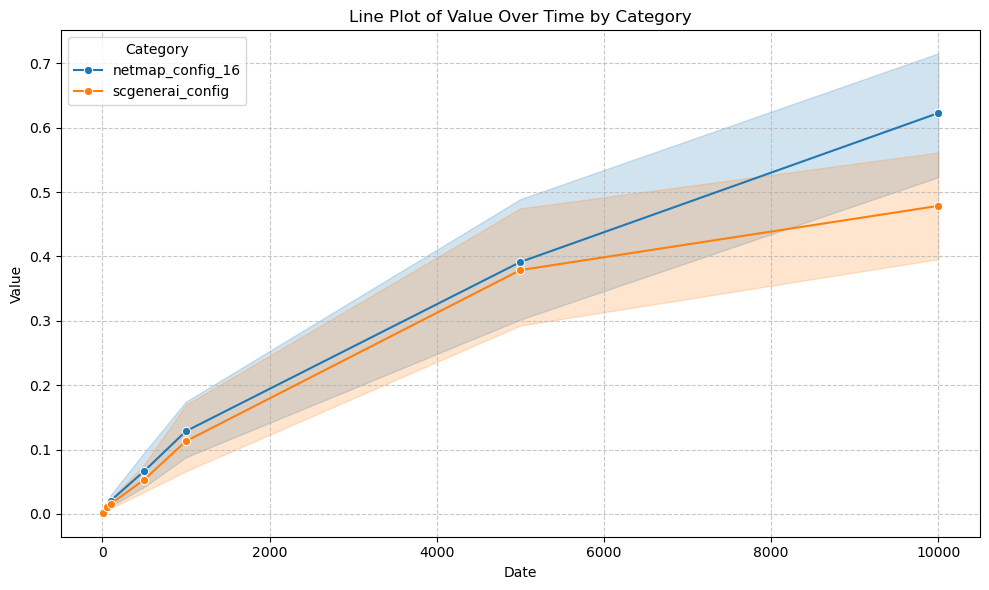

In [23]:
# 3. Example with multiple lines (using 'hue')
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_overlaps[all_overlaps.method.isin(['netmap_config_16', 'scgenerai_config'])], x='n_top', y='on_target', hue='method', marker='o')
# 'hue' separates lines by the 'Category' column
# 'marker' adds markers to the data points
# 'errorbar=None' removes confidence intervals (useful for individual lines)

plt.title('Line Plot of Value Over Time by Category')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category') # Add a legend for the 'hue' variable
plt.tight_layout()
plt.show()

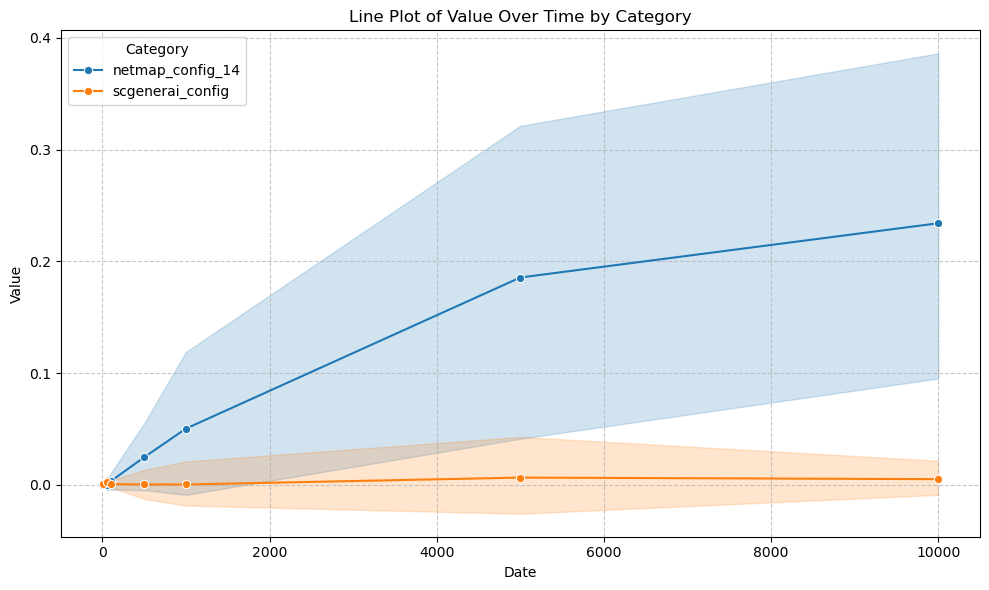

In [25]:
# 3. Example with multiple lines (using 'hue')
plt.figure(figsize=(10, 6))
sns.lineplot(data=all_overlaps[all_overlaps.method.isin(['netmap_config_14', 'scgenerai_config'])], x='n_top', y='difference', hue='method', marker='o')
# 'hue' separates lines by the 'Category' column
# 'marker' adds markers to the data points
# 'errorbar=None' removes confidence intervals (useful for individual lines)

plt.title('Line Plot of Value Over Time by Category')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category') # Add a legend for the 'hue' variable
plt.tight_layout()
plt.show()

In [42]:
all_overlaps

,Unnamed: 0,method,n_top,on_target,off_target,net,difference
0,0,netmap_config_7,10,0.000000,0.000000,net_105_14145_net_76_12762_net_51_13833,0.000000
1,1,netmap_config_7,10,0.000000,0.000000,net_105_14145_net_76_12762_net_51_13833,0.000000
2,2,netmap_config_7,50,0.000000,0.000000,net_105_14145_net_76_12762_net_51_13833,0.000000
3,3,netmap_config_7,50,0.000000,0.000000,net_105_14145_net_76_12762_net_51_13833,0.000000
4,4,netmap_config_7,100,0.000000,0.000000,net_105_14145_net_76_12762_net_51_13833,0.000000
...,...,...,...,...,...,...,...
261,9,scgenerai_config,1000,0.117117,0.153153,net_149_13167_net_51_13496_net_59_13649,-0.036036
262,10,scgenerai_config,5000,0.313187,0.307692,net_149_13167_net_51_13496_net_59_13649,0.005495
263,11,scgenerai_config,5000,0.567568,0.603604,net_149_13167_net_51_13496_net_59_13649,-0.036036
264,12,scgenerai_config,10000,0.329670,0.329670,net_149_13167_net_51_13496_net_59_13649,0.000000


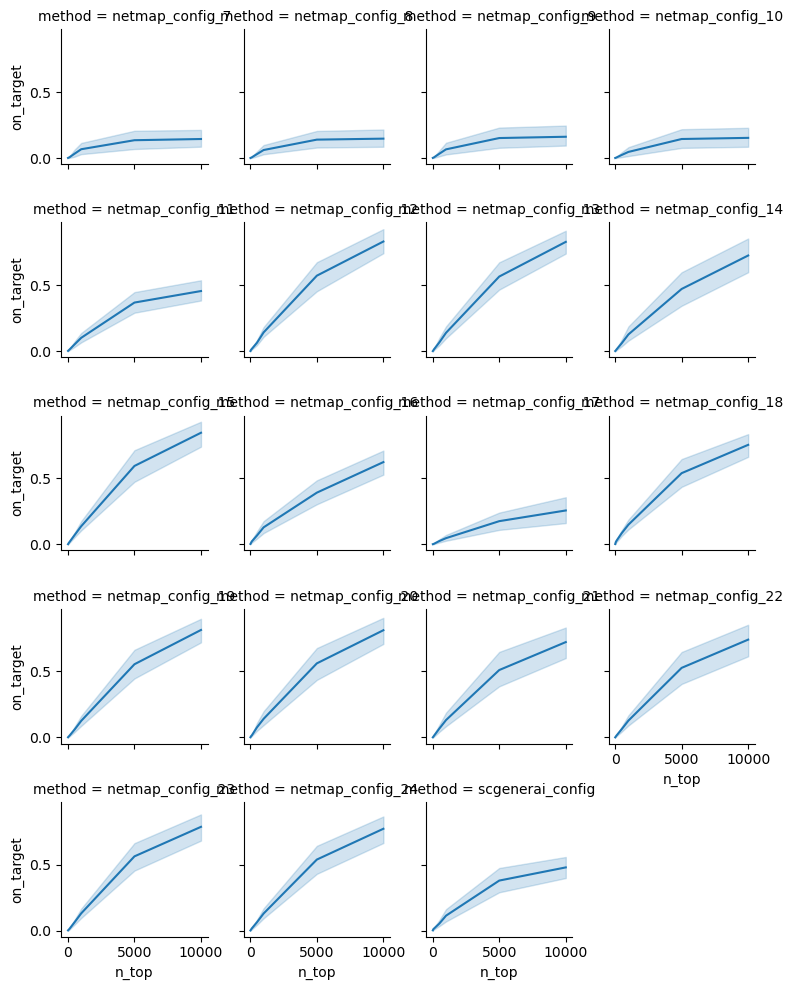

In [48]:

g = sns.FacetGrid(all_overlaps, col="method", col_wrap=4, height=2)
g.map(sns.lineplot, "n_top", "on_target")

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='method', y='time_method_minutes', data=times)
sns.stripplot(x='method', y='time_method_minutes', data=times, color='black', size=5, jitter=True) # Adds individual points
plt.title('Wall times by Method')
plt.xlabel('Method')
plt.ylabel('Wall Time')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import scanpy as sc

In [29]:
import os
import yaml

def read_all_yaml_files(root_dir):
    """
    Reads all YAML files in a tree of directories starting from root_dir.

    Args:
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_yaml_data = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_yaml_data

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(('results.yaml', 'results.yml')):
                filepath = os.path.join(dirpath, filename)
                try:
                    with open(filepath, 'r', encoding='utf-8') as file:
                        yaml_data = yaml.safe_load(file)
                        if yaml_data is not None:  # Ensure the file wasn't empty
                            
                            yaml_data['net'] = op.basename(op.dirname(filepath))
                            yaml_data['config'] = op.basename(op.dirname(op.dirname(op.dirname(filepath))))
                            all_yaml_data.append(yaml_data)
                        else:
                            print(f"Warning: YAML file '{filepath}' is empty or contains no data.")
                        
                except yaml.YAMLError as exc:
                    print(f"Error parsing YAML file '{filepath}': {exc}")
                except Exception as e:
                    print(f"Error reading file '{filepath}': {e}")
    return all_yaml_data

In [ ]:
op.basename(op.dirname('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap'))

'results'

In [30]:
all_times = read_all_yaml_files('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap')

In [31]:
all_times = pd.DataFrame(all_times)

In [32]:
all_times['tool_time'] = all_times['time_elapsed_netmap']/60

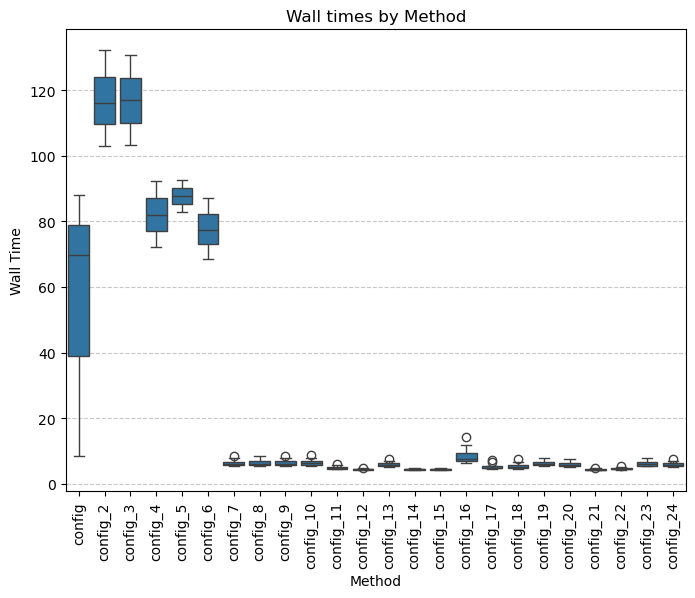

In [34]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='config', y='tool_time', data=all_times)
plt.title('Wall times by Method')
plt.xlabel('Method')
plt.ylabel('Wall Time')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import sys
import os.path as op
import os
sys.path.append('/data_nfs/og86asub/netmap/netmap-evaluation/')

import anndata
from netmap.src.utils.netmap_config import NetmapConfig
from src.methods.csnet.csnet_config import CsNetConfig
from src.methods.scgenerai.scgenerai_config import ScGeneRAIConfig
from src.data_simulation.data_simulation_config import DataSimulationConfig
from src.pipelines.utils import PipelineConfig
from captum.attr import GradientShap



import numpy as np
import scanpy as sc
import pandas as pd
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
import scipy.sparse as scs
from sklearn.cluster import SpectralClustering

from src.utils import write_config


def downstream_recipe(adata)-> anndata.AnnData:
    """
    Downstream reciepe for an LRP anndata object:
    TODO: replace the config dict, to pass values
    """
    config = {'min_cells':1, 'n_neighbors': 30, 'leiden_resolution': 0.1, 'n_components': 30, 'knn_neighbors': 30}
    sc.pp.filter_genes(adata, min_cells=config['min_cells'])
    #sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
    #sc.pp.normalize_total(adata)
    #sc.pp.log1p(adata)

    sc.tl.pca(adata, svd_solver = 'randomized', zero_center = False)

    sc.pp.neighbors(adata, n_neighbors=config['knn_neighbors'])
    sc.tl.leiden(adata, resolution=config['leiden_resolution'])

    sc.tl.umap(adata, n_components = config['n_components'])
    return adata


def spectral_clustering(adata, n_clu = 2, key_added = 'spectral'):
    """
    Run sklearn spectral clustering on the neighbour matrix in the anndata object.

    Args:
    adata: Anndata object
    n_clu: Number of clusters to compute
    key_added: The key to add the new labelling to [Default: spectral]
    """
    sc.pp.neighbors(adata)
    ssc = SpectralClustering(n_clusters=n_clu,assign_labels='discretize',random_state=0, affinity= 'precomputed_nearest_neighbors').fit(adata.obsp['distances'])
    counter = 0
    key_added_t = key_added
    while key_added_t in adata.obs.columns:
        counter = counter + 1
        key_added_t = f'{key_added}_{counter}'
    adata.obs[key_added_t] = ssc.labels_
    adata.obs[key_added_t] = pd.Categorical(adata.obs[key_added_t])
    return adata


def unify_group_labelling(adata, grn_adata, col_adata, col_grn_adata, return_mapping=False):
    """
    Adjust group labelling such that grn_adata has the same group label than the 
    corresponding column in adata based on the grn column.

    Returns the data objects and a score of the matching as the cost of the matching
    divided by the number of cells.
    
    """

    cm = contingency_matrix(adata.obs[col_adata], grn_adata.obs[col_grn_adata])
    row_ind, col_ind = linear_sum_assignment(cm, maximize = True)
    
    names_ad = np.unique(adata.obs[col_adata])
    print(names_ad)
    names_grn = np.unique(grn_adata.obs[col_grn_adata])
    mapping = {}
    reverse_mapping = {}
    for i in range(len(row_ind)):
        reverse_mapping[names_grn[col_ind[i]]] = names_ad[row_ind[i]]

    col_grn_adata_remapped = col_grn_adata + '_remap'
    if isinstance(np.unique(grn_adata.obs[col_grn_adata])[0], str):
        grn_adata.obs[col_grn_adata_remapped] = [reverse_mapping[a] for a in grn_adata.obs[col_grn_adata]]
    else:
        grn_adata.obs[col_grn_adata_remapped] = [reverse_mapping[int(a)] for a in grn_adata.obs[col_grn_adata]]

    grn_adata.obs[col_grn_adata_remapped] = pd.Categorical(grn_adata.obs[col_grn_adata_remapped])

    score = cm[row_ind, col_ind].sum()/adata.obs.shape[0]
    if return_mapping:
        return adata, grn_adata, score, reverse_mapping
    else:
        return adata, grn_adata, score

def compute_egde_overlaps_simple(grn_adata, net_list):
    print(grn_adata.var.columns)
    net_recovery = {}
    for net_name, net in net_list:
        print(net_name)
        print(net)
        print(grn_adata.var)
        overlap_count = (pd.merge(grn_adata.var, net, on=['source', 'target'], how='inner').shape[0])
        print(overlap_count)
        reverse_overlap = (pd.merge(grn_adata.var, net, on=['target', 'source'], how='inner').shape[0])
        net_size = net.shape[0]
        overlap_perc = overlap_count/net_size
        reverse_overlap_perc = reverse_overlap/net_size
        net_recovery[net_name] = {'edge_overlap':overlap_count, 'net_size': net_size, 'overlap_percent':overlap_perc, 'reverse_overlap_percent': reverse_overlap_perc}

        net_recovery['total_number_edges'] = grn_adata.var.shape[0]
    return net_recovery



def process(grn_adata):
    if not scs.issparse(grn_adata.X):
        grn_adata.X[np.isnan(grn_adata.X) ] = 0
    grn_adata = downstream_recipe(grn_adata)off_target
    grn_adata = spectral_clustering(grn_adata)
    return grn_adata

def get_top_edges_per_cell(grn_adata, top_edges):
    

    b = np.argpartition(grn_adata.X, top_edges)    # top 3 values from each row
    top_idx = b[:,-top_edges:]

    print(grn_adata.var.columns)
    scgenerai_var_index_np = np.array(grn_adata.var)
    top_edges_per_cell = pd.DataFrame(np.concat(scgenerai_var_index_np[top_idx]))
    top_edges_per_cell.columns = ['source', 'target', 'n_cells']
    top_edges_per_cell['cell_barcode'] = np.repeat(grn_adata.obs.index, repeats=top_edges)
    return top_edges_per_cell



def get_top_edges_per_cell_per_cluster(grn_adata, nets, cluster_var = 'spectral_remap', top_edges=5000):
    
    grns = grn_adata.obs[cluster_var].unique()
    on_target = []
    off_target = []
    # Correct cluster :)
    for i in range(len(nets)):
        for j in range(len(grns)):
            clu = grns[j]
            grn = nets[i]
            print(clu)
            print(f"Cluster {clu} -- GRN {grn[0]}")

            grn_adata_sub = grn_adata[grn_adata.obs[cluster_var] == clu]
            # identify the genes with the highest mean
            top_edges_per_cell = get_top_edges_per_cell(grn_adata_sub,  top_edges)
            agg = top_edges_per_cell.merge(grn[1], left_on=['source', 'target'], right_on = ['source', 'target']).loc[:,['source', 'target']].groupby(['source', 'target']).value_counts()
            agg = agg.reset_index()
            
            if i == j:
                on_target.append(agg.shape[0]/grn[1].shape[0])
            else: 
                off_target.append(agg.shape[0]/grn[1].shape[0])
    return on_target, off_target


def build_augmented_network(net):
    """
    Insert an edge between two genes if they are regulated by the same gene.
    """
    augmented_net = []
    for s in net.source.unique():
        targets = net[net.source == s].target.unique()
        cro = np.transpose([np.tile(targets, len(targets)), np.repeat(targets, len(targets))])
        augmented_net.append(cro)
    augmented_net = pd.DataFrame(np.vstack(augmented_net))
    augmented_net.columns = ['source', 'target']
    augmented_net['edge' ] = augmented_net['source']+'_'+augmented_net['target']
    return augmented_net


def compute_metrics(grn_ads, nets, group_key='grn'):
    collect_results = {}
    for method in grn_ads:
        print(method)
        try:
            try:
                collect_results[method] = compute_egde_overlaps_simple(grn_ads[method], nets)
            
                grn_ads[method] = process(grn_ads[method])
                grn_ads[method], grn_ads[method], score = unify_group_labelling(grn_ads[method], grn_ads[method], group_key, 'spectral')
                collect_results[method]['clustering_score'] = float(score)
                try:
                    print('top 100')
                    ont, oft = get_top_edges_per_cell_per_cluster(grn_ads[method], nets, cluster_var = 'spectral_remap', top_edges=5000)
                    collect_results[method]['on_grn_overlap'] = ont
                    collect_results[method]['off_grn_overlap'] = oft
                except:
                    print('error')
            except KeyError:
                print('empty anndata')

        except FileNotFoundError:
            collect_results[method] = 'no data'
    return collect_results



In [ ]:
dataset_config = DataSimulationConfig.read_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/results/configurations/data_simulation/config_easy/net_105_14145_net_76_12762_net_51_13833.config.yaml')
pipeline_config = PipelineConfig.read_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/configurations/pipelines/pipeline_config.yaml')


    # read network files
    
nets = [(op.basename(op.dirname(filename)), pd.read_csv(op.join(pipeline_config.clustered_network_dir, filename), sep=dataset_config.separator)) for filename in dataset_config.edgelist]
off_net = [(op.basename(op.dirname(filename)), pd.read_csv(op.join(pipeline_config.clustered_network_dir, filename), sep=dataset_config.separator)) for filename in dataset_config.common_edges]

baseadata = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/simulated_data/config_easy/net_105_14145_net_76_12762_net_51_13833/data.h5ad')
data = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap/config_14/config_easy/net_105_14145_net_76_12762_net_51_13833/grn_lrp.h5ad')

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [ ]:
np.unique(np.array([1,2,32,2,2]))

array([ 1,  2, 32])

In [ ]:
sc.pp.highly_variable_genes(data)
data = downstream_recipe(data)

In [ ]:
sc.pl.umap(data, color='grn')

In [ ]:
compute_metrics({'scgenerai':data}, nets)

scgenerai
Index(['source', 'target', 'n_cells'], dtype='object')
net_105_14145
    source    target
0    GATA3     ZC3H8
1    GATA3    ZNF217
2    GATA3    ARID5B
3    GATA3    ZNF503
4    GATA3    ATP2B1
..     ...       ...
105  CREB5  ATP6V0E1
106  CREB5      DGKG
107  CREB5  MAPKAPK3
108  CREB5   RASGRP3
109  CREB5       RDX

[110 rows x 2 columns]
               source  target  n_cells
index                                 
ACADVL_ACADVL  ACADVL  ACADVL      460
ACTR6_ACADVL    ACTR6  ACADVL      537
ADA_ACADVL        ADA  ACADVL      463
ADD1_ACADVL      ADD1  ACADVL      534
ADIPOQ_ACADVL  ADIPOQ  ACADVL      480
...               ...     ...      ...
ZFHX2_ZW10      ZFHX2    ZW10      495
ZNF217_ZW10    ZNF217    ZW10      493
ZNF503_ZW10    ZNF503    ZW10      509
ZNF507_ZW10    ZNF507    ZW10      510
ZW10_ZW10        ZW10    ZW10      528

[53807 rows x 3 columns]
110
net_76_12762
     source  target
0      KAT7  CREBBP
1      KAT7   KAT2B
2      KAT7   TRRAP
3      KAT7   K

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[1. 2.]
top 100
1.0
Cluster 1.0 -- GRN net_105_14145
Index(['source', 'target', 'n_cells'], dtype='object')
2.0
Cluster 2.0 -- GRN net_105_14145
Index(['source', 'target', 'n_cells'], dtype='object')
1.0
Cluster 1.0 -- GRN net_76_12762
Index(['source', 'target', 'n_cells'], dtype='object')
2.0
Cluster 2.0 -- GRN net_76_12762
Index(['source', 'target', 'n_cells'], dtype='object')


{'scgenerai': {'net_105_14145': {'edge_overlap': 110,
   'net_size': 110,
   'overlap_percent': 1.0,
   'reverse_overlap_percent': 1.0},
  'total_number_edges': 53807,
  'net_76_12762': {'edge_overlap': 163,
   'net_size': 163,
   'overlap_percent': 1.0,
   'reverse_overlap_percent': 1.0},
  'clustering_score': 1.0,
  'on_grn_overlap': [0.8454545454545455, 0.6319018404907976],
  'off_grn_overlap': [0.3090909090909091, 0.25153374233128833]}}

In [ ]:
compute_egde_overlaps_simple(data, nets)

Index(['source', 'target', 'n_cells'], dtype='object')
net_105_14145
    source    target
0    GATA3     ZC3H8
1    GATA3    ZNF217
2    GATA3    ARID5B
3    GATA3    ZNF503
4    GATA3    ATP2B1
..     ...       ...
105  CREB5  ATP6V0E1
106  CREB5      DGKG
107  CREB5  MAPKAPK3
108  CREB5   RASGRP3
109  CREB5       RDX

[110 rows x 2 columns]
               source  target  n_cells
index                                 
ACADVL_ACADVL  ACADVL  ACADVL      492
ADA_ACADVL        ADA  ACADVL      491
ADIPOQ_ACADVL  ADIPOQ  ACADVL      492
AEBP1_ACADVL    AEBP1  ACADVL      492
APAF1_ACADVL    APAF1  ACADVL      493
...               ...     ...      ...
ZFHX2_ZW10      ZFHX2    ZW10      508
ZNF217_ZW10    ZNF217    ZW10      508
ZNF503_ZW10    ZNF503    ZW10      509
ZNF507_ZW10    ZNF507    ZW10      506
ZW10_ZW10        ZW10    ZW10      505

[54896 rows x 3 columns]
94
net_76_12762
     source  target
0      KAT7  CREBBP
1      KAT7   KAT2B
2      KAT7   TRRAP
3      KAT7   KAT2A
4     

{'net_105_14145': {'edge_overlap': 94,
  'net_size': 110,
  'overlap_percent': 0.8545454545454545,
  'reverse_overlap_percent': 0.8545454545454545},
 'total_number_edges': 54896,
 'net_76_12762': {'edge_overlap': 178,
  'net_size': 163,
  'overlap_percent': 1.0920245398773005,
  'reverse_overlap_percent': 1.0920245398773005}}

In [ ]:
data.var = data.var.reset_index()

In [ ]:
baseadata.var

,genes
ACAN,ACAN
ACE,ACE
ADARB1,ADARB1
ADSS1,ADSS1
AKAP8L,AKAP8L
...,...
ZNF268,ZNF268
ZNF281,ZNF281
ZNF750,ZNF750
ZNF77,ZNF77


In [ ]:
data.var.target = np.repeat(list(baseadata.var.genes), repeats=208)

In [ ]:
data.var.target

0           ACAN
1           ACAN
2           ACAN
3           ACAN
4           ACAN
          ...   
43259    ZNF804A
43260    ZNF804A
43261    ZNF804A
43262    ZNF804A
43263    ZNF804A
Name: target, Length: 43264, dtype: object

In [ ]:
np.repeat(baseadata.var.genes, times=208)

TypeError: repeat() got an unexpected keyword argument 'times'

In [ ]:
pd.merge(data.var, nets[0][1], on=['source', 'target'], how='inner')


,source,target


In [ ]:
grn_adata = data
net_list = nets

In [ ]:
grn_adata.var = grn_adata.var.reset_index()

In [ ]:
grn_adata.var.source.unique()
grn_adata.var.target.unique()

['ZNF804A']
Categories (1, object): ['ZNF804A']

In [ ]:

print(grn_adata.var.columns)
net_recovery = {}
for net_name, net in net_list:
    print(net_name)
    print(net.source.unique())
    print(grn_adata.var)
    overlap_count = (pd.merge(grn_adata.var, net, on=['source', 'target'], how='inner').shape[0])
    print(overlap_count)
    reverse_overlap = (pd.merge(grn_adata.var, net, on=['target', 'source'], how='inner').shape[0])
    net_size = net.shape[0]
    overlap_perc = overlap_count/net_size
    reverse_overlap_perc = reverse_overlap/net_size
    net_recovery[net_name] = {'edge_overlap':overlap_count, 'net_size': net_size, 'overlap_percent':overlap_perc, 'reverse_overlap_percent': reverse_overlap_perc}

    net_recovery['total_number_edges'] = grn_adata.var.shape[0]



Index(['index', 'source', 'target'], dtype='object')
net_63_13257
['ZNF281' 'ZEB1' 'SNAI1' 'TWIST1' 'HOXA7' 'TWIST2' 'SNAI2' 'ZEB2' 'KLF8'
 'ZNF77' 'MEIS2' 'SATB2' 'ZKSCAN3' 'GRHL2' 'KLF17']
                 index   source   target
0         ACAN_ZNF804A     ACAN     ACAN
1          ACE_ZNF804A      ACE     ACAN
2       ADARB1_ZNF804A   ADARB1     ACAN
3        ADSS1_ZNF804A    ADSS1     ACAN
4       AKAP8L_ZNF804A   AKAP8L     ACAN
...                ...      ...      ...
43259   ZNF268_ZNF804A   ZNF268  ZNF804A
43260   ZNF281_ZNF804A   ZNF281  ZNF804A
43261   ZNF750_ZNF804A   ZNF750  ZNF804A
43262    ZNF77_ZNF804A    ZNF77  ZNF804A
43263  ZNF804A_ZNF804A  ZNF804A  ZNF804A

[43264 rows x 3 columns]
131
net_51_13886
['CARF' 'NR3C2' 'TFCP2' 'SRY' 'CXXC1' 'SOX11' 'MECP2' 'CREB3L2']
                 index   source   target
0         ACAN_ZNF804A     ACAN     ACAN
1          ACE_ZNF804A      ACE     ACAN
2       ADARB1_ZNF804A   ADARB1     ACAN
3        ADSS1_ZNF804A    ADSS1     ACAN
4   